# WHY DO CUSTOMERS CHURN? 客户为什么流失

In [25]:
import pandas as pd
df = pd.read_excel("Telco_customer_churn.xlsx")

df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

看结构 确认
- 总共有多少用户
- 每个变量类型

## step 2 确定核心变量
客户信息
- Tenure Months 客户使用时间
- Contract 订阅类型
- Internet Service 产品类型
- Monthly Charges 价格
- Payment Method 支付方式
- Churn Label 是否流失

## step 3 数据清洗
这个数据集的常见问题
`TotalCharges`是string 但是我看不出来啊  dtype写的是object 一个意思吗？
回答 显示object说明就是字符串
三种类型 int float object 整数 小数 字符串

In [26]:
df['Total Charges']= pd.to_numeric(df['Total Charges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [27]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

## step 4 第一件事：整体流失率

In [28]:
churn_rate = df['Churn Label'].value_counts(normalize=True)
print(churn_rate)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


这串代码需要解释一下 怎么最后计数变成了百分比

> about 27% of customers have churned

## step 5 分析churn 和tenure

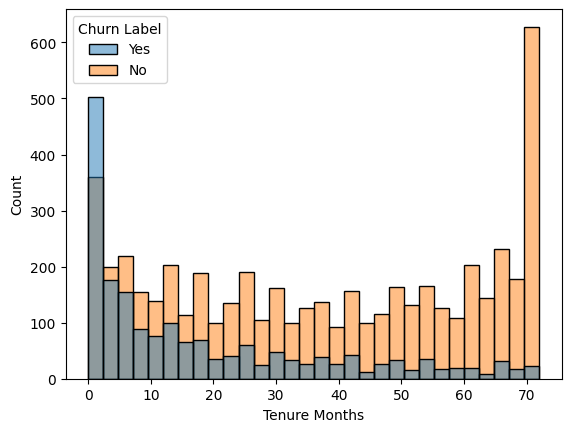

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='Tenure Months', hue='Churn Label', bins=30)
plt.show()

# hue给数据分颜色 BiN指定桶的数量 自动切分每个桶多少个月；如果是binwidth就是制定每个桶多少个月
# 大数据用Bins 确定就好了 不然图会特别大

一个经典结论是：
**新用户更容易流失**
业务解释：
> customers with shorter tenure show a significantly higher churn probability

## step 6 分析contract
这个变量通常影响最大
两个变量都是类别变量 contract 和 churn label 用crosstab

In [30]:
pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


> customers with month-to-month contracts churn significantly more often

## step 7 分析MonthlyCharges
看价格和churn的关系 事实上分析的是 流失用户和未流失用户的月费 重点是月费 然后分成两类
即 数值/分类

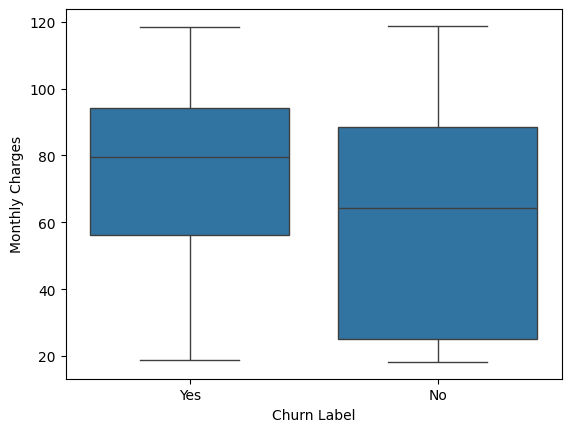

In [36]:
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges')
plt.show()

## step 8 payment method

In [38]:
pd.crosstab(df['Payment Method'], df['Churn Label'], normalize='index')

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


Electronic check churn最高

## step 9 dashboard 用tableau或power bi

1️⃣ Overall churn rate  
2️⃣ churn vs tenure  
3️⃣ churn vs contract  
4️⃣ churn vs monthly charges  

## step 10 businees insight
insight 1:  
insight 2:  
..

step 11 做个简单预测（可选

In [39]:
df.to_csv("telco_clean.csv", index=False)